# Clustering and Initialization: k-means vs. k-means++

This notebook compares random initialization and k-means++ initialization. The k-means algorithm is written from scratch with NumPy.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42
TRIALS = 50
MAX_ITER = 100
TOL = 1e-4

DATA_DIR = Path("/Users/shynggys.babir/Desktop/Data")
red = pd.read_csv(DATA_DIR / "winequality-red.csv", sep=";")
white = pd.read_csv(DATA_DIR / "winequality-white.csv", sep=";")
names_text = (DATA_DIR / "winequality.names").read_text(encoding="latin1")

red["wine_type"] = "red"
white["wine_type"] = "white"
df = pd.concat([red, white], ignore_index=True)

print("Data folder:", DATA_DIR)
print("df shape:", df.shape)
print("names file first line:", names_text.splitlines()[0])
display(df.head())

Data folder: /Users/shynggys.babir/Desktop/Data
df shape: (6497, 13)
names file first line: Citation Request:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## k-means Code

Inertia is the sum of squared distances from each point to its closest centroid.

In [2]:
def d2(X, C):
    return ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)


def start_centers(X, k, method, rng):
    if method == "random":
        return X[rng.choice(len(X), k, replace=False)].astype(float)

    centers = [X[rng.integers(len(X))].astype(float)]
    for _ in range(k - 1):
        closest = d2(X, np.array(centers)).min(axis=1)
        p = closest / closest.sum()
        centers.append(X[rng.choice(len(X), p=p)].astype(float))
    return np.array(centers)


def kmeans(X, k, method, seed):
    rng = np.random.default_rng(seed)
    C = start_centers(X, k, method, rng)

    for it in range(1, MAX_ITER + 1):
        labels = d2(X, C).argmin(axis=1)
        new_C = C.copy()

        for j in range(k):
            pts = X[labels == j]
            new_C[j] = pts.mean(axis=0) if len(pts) else X[rng.integers(len(X))]

        shift = np.sqrt(((new_C - C) ** 2).sum(axis=1)).max()
        C = new_C
        if shift < TOL:
            break

    dist = d2(X, C)
    labels = dist.argmin(axis=1)
    inertia = dist[np.arange(len(X)), labels].sum()
    return C, labels, float(inertia), it

## Datasets

I use two synthetic datasets and the Wine Quality data. Wine is the high-dimensional dataset because it has 11 numeric features.

In [3]:
def blobs(centers, std, seed, n=150):
    rng = np.random.default_rng(seed)
    X, y = [], []
    for i, c in enumerate(centers):
        X.append(rng.normal(c, std, size=(n, 2)))
        y.append(np.full(n, i))
    return np.vstack(X), np.concatenate(y)


def scale(X):
    return (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12)


X_sep, y_sep = blobs([[-5, -5], [-5, 5], [5, -5], [5, 5]], 0.55, 1)
X_overlap, y_overlap = blobs([[-3, 0], [0, 0], [3, 0], [0, 3]], 1.60, 2)

features = [c for c in df.columns if c not in ["quality", "wine_type"]]
X_wine = scale(df[features].to_numpy(float))
y_wine = (df["wine_type"] == "white").astype(int).to_numpy()

data = {
    "Separated synthetic": (X_sep, y_sep, 4),
    "Overlapping synthetic": (X_overlap, y_overlap, 4),
    "Wine Quality": (X_wine, y_wine, 2),
}

for name, (X, y, k) in data.items():
    print(name, X.shape, "K=", k)

Separated synthetic (600, 2) K= 4
Overlapping synthetic (600, 2) K= 4
Wine Quality (6497, 11) K= 2


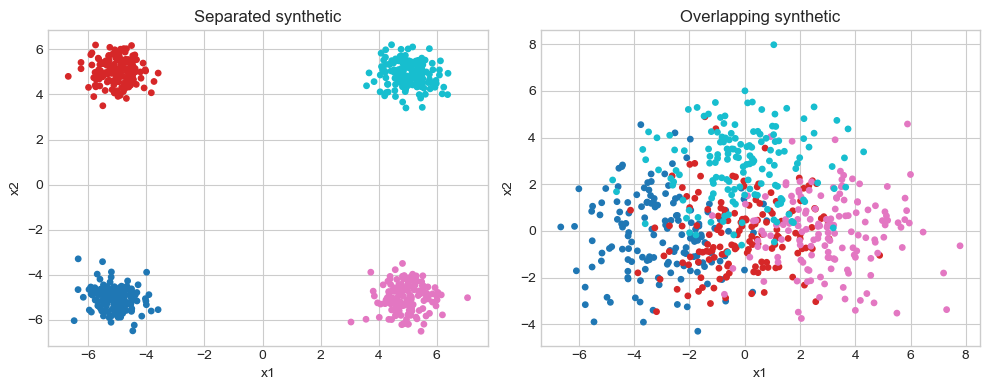

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X_sep[:, 0], X_sep[:, 1], c=y_sep, cmap="tab10", s=15)
ax[0].set_title("Separated synthetic")
ax[1].scatter(X_overlap[:, 0], X_overlap[:, 1], c=y_overlap, cmap="tab10", s=15)
ax[1].set_title("Overlapping synthetic")
for a in ax:
    a.set_xlabel("x1")
    a.set_ylabel("x2")
plt.tight_layout()
plt.show()

## Experiments

Each method is run 50 times on each dataset. I record inertia and use standard deviation as the stability measure.

In [5]:
methods = ["random", "kmeans++"]
offset = {"Separated synthetic": 0, "Overlapping synthetic": 10000, "Wine Quality": 40000}
rows = []
best = {}

for name, (X, y, k) in data.items():
    for m_id, method in enumerate(methods):
        best_inertia = np.inf
        for trial in range(1, TRIALS + 1):
            seed = SEED + offset[name] + 1000 * m_id + trial
            C, labels, inertia, it = kmeans(X, k, method, seed)
            rows.append([name, method, trial, inertia, it])
            if inertia < best_inertia:
                best_inertia = inertia
                best[(name, method)] = (C, labels, inertia)

results = pd.DataFrame(rows, columns=["dataset", "method", "trial", "inertia", "iterations"])
summary = results.groupby(["dataset", "method"])["inertia"].agg(["mean", "std", "min", "max"]).reset_index()
display(summary.round(2))

,dataset,method,mean,std,min,max
0,Overlapping synthetic,kmeans++,2021.11,49.92,2011.01,2265.92
1,Overlapping synthetic,random,2020.49,46.88,2011.01,2252.77
2,Separated synthetic,kmeans++,357.31,0.00,357.31,357.31
3,Separated synthetic,random,2614.23,3482.61,357.31,7918.24
4,Wine Quality,kmeans++,57128.81,1430.20,56143.92,60530.09
5,Wine Quality,random,57578.82,1471.06,56143.92,60530.09


In [6]:
t = summary.pivot(index="dataset", columns="method", values=["mean", "std"])
compare = pd.DataFrame(index=t.index)
compare["mean_reduction_%"] = 100 * (t[("mean", "random")] - t[("mean", "kmeans++")]) / t[("mean", "random")]
compare["std_reduction_%"] = 100 * (t[("std", "random")] - t[("std", "kmeans++")]) / t[("std", "random")]
display(compare.reset_index().round(2))

,dataset,mean_reduction_%,std_reduction_%
0,Overlapping synthetic,-0.03,-6.48
1,Separated synthetic,86.33,100.00
2,Wine Quality,0.78,2.78


## Plots

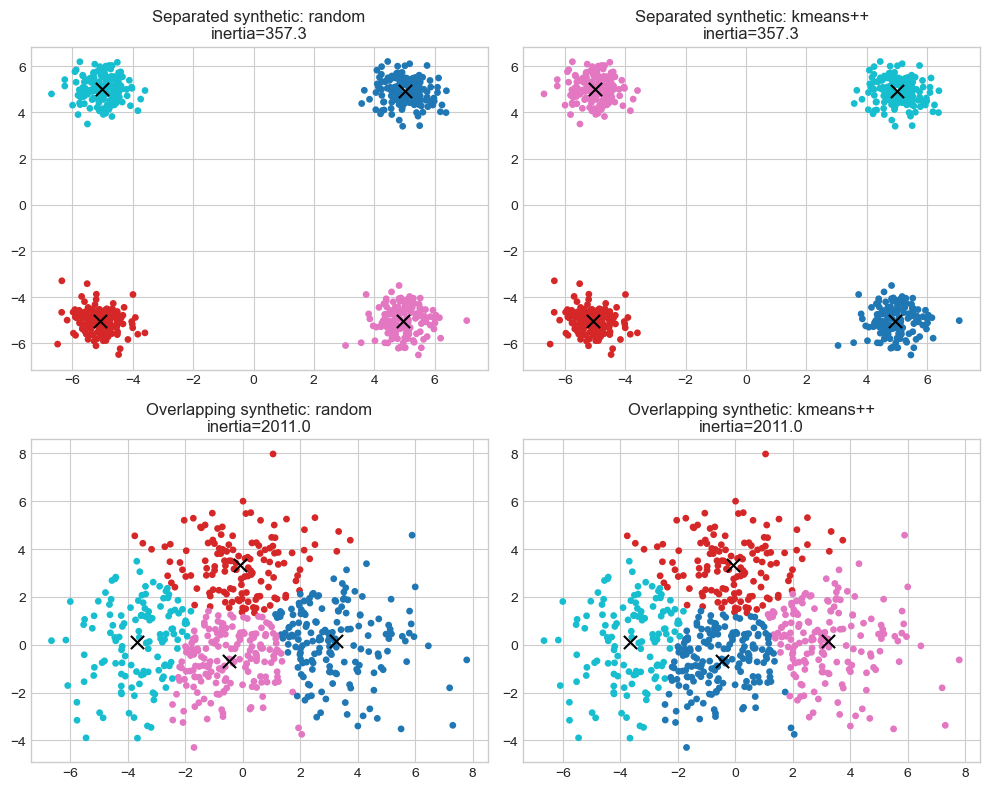

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
for r, (name, X) in enumerate([("Separated synthetic", X_sep), ("Overlapping synthetic", X_overlap)]):
    for c, method in enumerate(methods):
        C, labels, inertia = best[(name, method)]
        ax[r, c].scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=15)
        ax[r, c].scatter(C[:, 0], C[:, 1], c="black", marker="x", s=90)
        ax[r, c].set_title(f"{name}: {method}\ninertia={inertia:.1f}")
plt.tight_layout()
plt.show()

/var/folders/9t/17pwy7y57q963jrl_zb11kx80000gn/T/ipykernel_40096/2526589505.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot(vals, labels=["random", "k-means++"], showmeans=True)
/var/folders/9t/17pwy7y57q963jrl_zb11kx80000gn/T/ipykernel_40096/2526589505.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot(vals, labels=["random", "k-means++"], showmeans=True)
/var/folders/9t/17pwy7y57q963jrl_zb11kx80000gn/T/ipykernel_40096/2526589505.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot(vals, labels=["random", "k-means++"], showmeans=True)


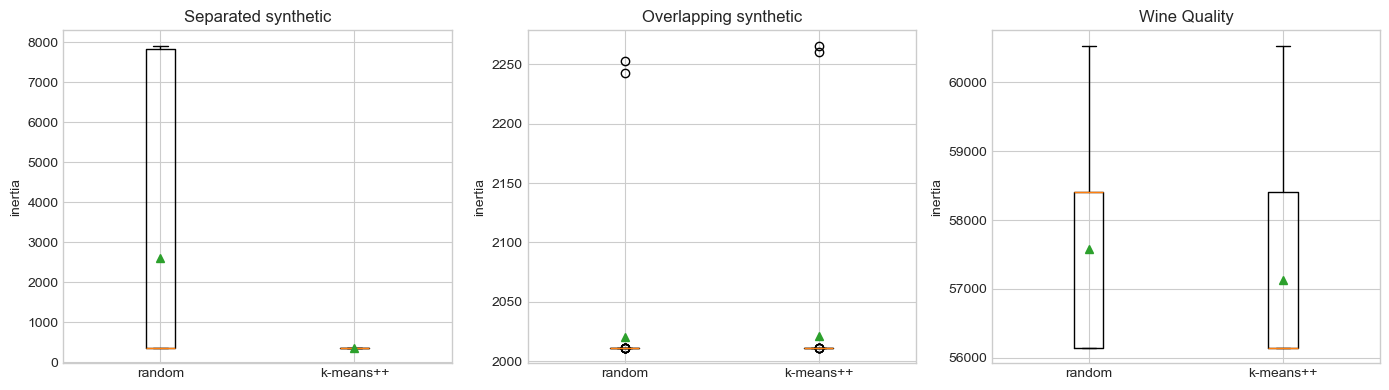

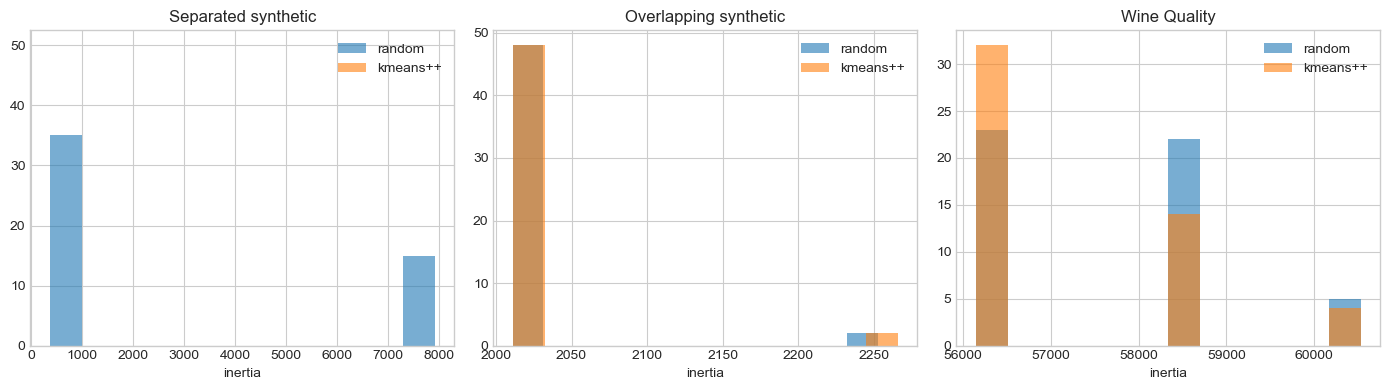

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, name in zip(ax, data.keys()):
    vals = [results[(results.dataset == name) & (results.method == m)].inertia for m in methods]
    a.boxplot(vals, labels=["random", "k-means++"], showmeans=True)
    a.set_title(name)
    a.set_ylabel("inertia")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, name in zip(ax, data.keys()):
    for m in methods:
        a.hist(results[(results.dataset == name) & (results.method == m)].inertia, bins=12, alpha=0.6, label=m)
    a.set_title(name)
    a.set_xlabel("inertia")
    a.legend()
plt.tight_layout()
plt.show()

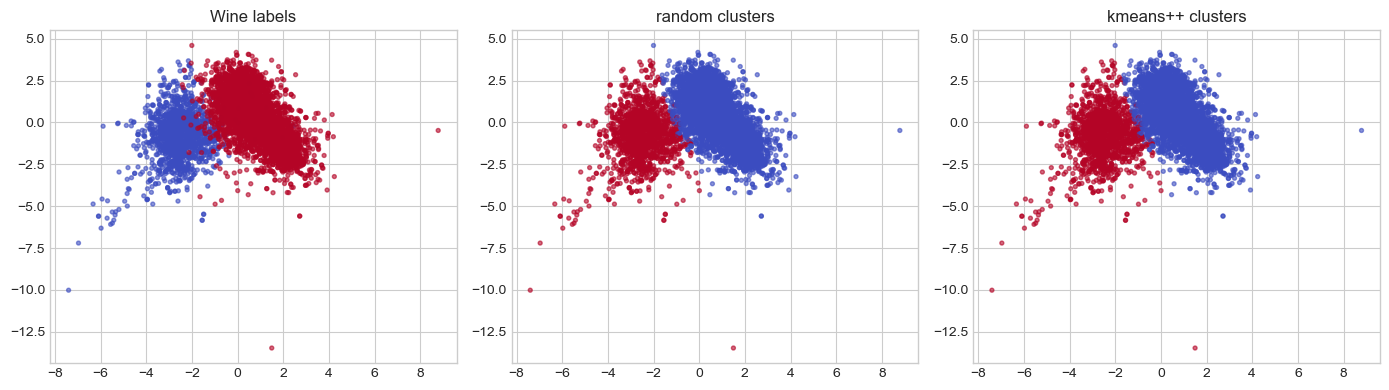

In [9]:
X0 = X_wine - X_wine.mean(axis=0)
_, _, Vt = np.linalg.svd(X0, full_matrices=False)
X2 = X0 @ Vt[:2].T

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].scatter(X2[:, 0], X2[:, 1], c=y_wine, cmap="coolwarm", s=8, alpha=0.6)
ax[0].set_title("Wine labels")
for i, m in enumerate(methods, start=1):
    C, labels, inertia = best[("Wine Quality", m)]
    ax[i].scatter(X2[:, 0], X2[:, 1], c=labels, cmap="coolwarm", s=8, alpha=0.6)
    ax[i].set_title(f"{m} clusters")
plt.tight_layout()
plt.show()

## Conclusion

K-means++ clearly helps on the separated synthetic data and gives a small improvement on the Wine Quality data. On the overlapping data it is not better in this run, which shows that k-means++ is useful but not a guarantee. It is still randomized and k-means can still converge to local minima.